<a href="https://colab.research.google.com/github/hagalaz-star/CV/blob/main/trailer_scene_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Failure Analysis of Vision-Language Scene Retrieval for Robot Perception

In [1]:
# import subprocess
# from pathlib import Path

# TRAILER_DIR = Path("/content/drive/MyDrive/trailer_project")
# OUTPUT_DIR = Path("/content/drive/MyDrive/trailer_project/scenes")

# video_files = list(TRAILER_DIR.glob("*.mp4"))

# for video_path in video_files:
#     movie_name = video_path.stem
#     movie_output_dir = OUTPUT_DIR / movie_name
#     movie_output_dir.mkdir(parents=True, exist_ok=True)

#     cmd = [
#         "scenedetect",
#         "-i", str(video_path),
#         "-o", str(movie_output_dir),
#         "detect-adaptive",
#         "list-scenes",
#         "save-images",
#         "-n", "1"
#     ]

#     print(f"Processing: {movie_name}")
#     subprocess.run(cmd)

In [2]:
!pip install scenedetect[opencv] opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 3.8 MB/s eta 0:00:00


In [3]:
from pathlib import Path

TRAILER_DIR = Path("/content/drive/MyDrive/trailer_project")
OUTPUT_DIR = Path("/content/drive/MyDrive/trailer_project/scenes")

In [4]:
from pathlib import Path
import os

for file in os.listdir(TRAILER_DIR):
    print(file)

Dune-Part-Three-Official-Trailer_720p.mp4
Interstellar-Trailer-Official_720p.mp4
BLADE-RUNNER-2049-Trailer_720p.mp4
Arrival-Trailer_720p.mp4
TENET-Final-Trailer_720p.mp4
scenes


In [5]:
!pip install transformers torch torchvision pillow tqdm pandas

In [6]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [7]:
arrival_dir = Path("/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p")
image_paths = sorted(list(arrival_dir.glob("*.jpg")))
print("Arrival keyframes:", len(image_paths))

Arrival keyframes: 110


In [8]:
from PIL import Image
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

img_path = image_paths[0]

image = Image.open(img_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.vision_model(pixel_values=inputs["pixel_values"])

print(type(output))

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>


CLIP의 vision encoder 출력 객체가 나온다. 설명하자면

CLIP 모델 내부에는 두 부분이 있다.

vision encoder  →  이미지를 벡터로 변환하는 부분

text encoder    →  텍스트를 벡터로 변환하는 부분

vision encoder가 이미지를 처리하고 나면 결과물을 객체 형태로 반환하는데, 그게 BaseModelOutputWithPooling

In [9]:
print(output.pooler_output.shape)

torch.Size([1, 768])


pooler_output은 CLIP vision model의 내부 출력

In [10]:
from PIL import Image
import torch
import numpy as np
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)
model.eval()

def extra_clip_embeddings(image_paths, model, processor, device):
  embeddings= []


  for image in image_paths:
    image = Image.open(image).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        # image_features= model.get_image_features(**inputs)
        output = model.vision_model(pixel_values=inputs["pixel_values"])
        image_features= model.visual_projection(output.pooler_output)

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    embeddings.append(image_features.cpu().numpy()[0])

  embeddings = np.array(embeddings).astype("float32")


  return embeddings



In [11]:
arrival_embeddings = extra_clip_embeddings(image_paths=image_paths, model=model, processor=processor, device=device)
print(arrival_embeddings.shape)

(110, 512)


In [12]:
print(type(arrival_embeddings))

<class 'numpy.ndarray'>


### BaseModelOutputWithPooling 은 최종 임베딩 벡터가 아니라 모델 출력 묶음 객체



In [13]:
print(len(image_paths))

110


In [14]:
len(image_paths) == arrival_embeddings.shape[0]

True

In [15]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 40.0 MB/s eta 0:00:00







# 유사도 검사

In [16]:
import faiss
import numpy as np

vectors= arrival_embeddings.astype(np.float32)
faiss.normalize_L2(vectors)

In [17]:
print(vectors.shape)

(110, 512)


In [18]:
index = faiss.IndexFlatL2(512)
index.add(vectors)

In [19]:
print(index.ntotal)

110


In [20]:
query_vector = vectors[0:1]
D, I = index.search(query_vector, k=5)

# D가 작을수록 유사
print("유사도 점수:", D)
print("비슷한 이미지 인덱스:", I)

유사도 점수: [[0.         0.20258993 0.24346443 0.2585708  0.27010894]]
비슷한 이미지 인덱스: [[ 0 32 96 37 30]]


In [21]:
vectors_ip = vectors.copy()
faiss.normalize_L2(vectors_ip)

In [22]:
index_ip = faiss.IndexFlatIP(512)
index_ip.add(vectors_ip)

In [23]:
query_vector_ip = vectors_ip[0].reshape(1, -1)

## IP: 높을수록 유사
ip_D, ip_I = index_ip.search(query_vector_ip, k=5)

In [24]:
print("유사도 점수:", ip_D)
print("비슷한 이미지 인덱스:", ip_I)

유사도 점수: [[1.         0.8987053  0.878268   0.87071455 0.86494595]]
비슷한 이미지 인덱스: [[ 0 32 96 37 30]]


# 검색 결과 시각화

In [25]:
import matplotlib.pyplot as plt
from PIL import Image


def search_show_image(query_idx, image_paths, vectors_ip, index_ip, k=5):
  query_vector = vectors_ip[query_idx: query_idx+1]
  scores, indices = index_ip.search(query_vector, k)

  plt.figure(figsize=(15,4))

  for i, idx in enumerate(indices[0]):
      image = Image.open(image_paths[idx]).convert('RGB')
      plt.subplot(1, k, i+1)
      plt.imshow(image)
      plt.axis("off")

      if idx == query_idx:
        plt.title("Query")

      else:
        plt.title("Result")

  plt.show()

  return scores, indices





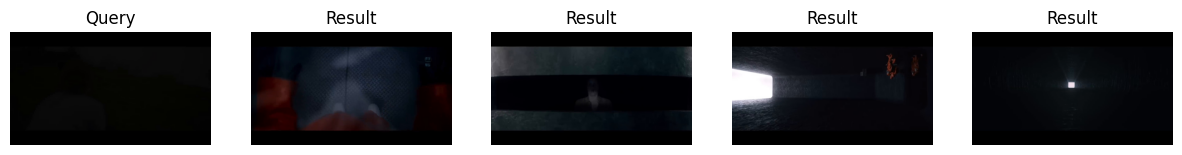

In [26]:
scores, indices = search_show_image(
    query_idx=0,
    image_paths=image_paths,
    vectors_ip=vectors_ip,
    index_ip=index_ip,
    k=5
)

결과 : 씬 분할 이미지 잘못 선정

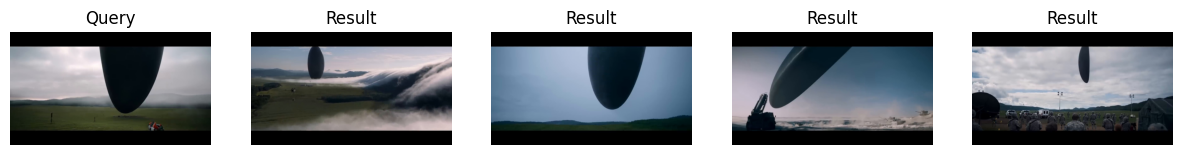

In [27]:
scores, indices = search_show_image(
    query_idx=25,
    image_paths=image_paths,
    vectors_ip=vectors_ip,
    index_ip=index_ip,
    k=5
)

전체 영화 트레일러 이미지로 유사도 찾아보기

In [28]:
from pathlib import Path

movie_dir = {
    "Arrival":Path("/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p"),
    "Blade_runner":Path("/content/drive/MyDrive/trailer_project/scenes/BLADE-RUNNER-2049-Trailer_720p"),
    "Dune_part_three":Path("/content/drive/MyDrive/trailer_project/scenes/Dune-Part-Three-Official-Trailer_720p"),
    "Interstellar":Path("/content/drive/MyDrive/trailer_project/scenes/Interstellar-Trailer-Official_720p"),
    "Tenet":Path("/content/drive/MyDrive/trailer_project/scenes/TENET-Final-Trailer_720p"),
}

In [29]:
image_paths_by_movie = {}

all_image_paths = []
metadata = []

for movie_title, movie_path in movie_dir.items():
  image_paths = sorted(list(movie_path.glob("*.jpg")))
  image_paths_by_movie[movie_title] = image_paths

  print(movie_title, "keyframes:", len(image_paths))

  for idx, path in enumerate(image_paths):
    all_image_paths.append(path)
    metadata.append({
        "movie_title": movie_title,
        "keyframe_idx": idx,
        "image_path": str(path)
    })

Arrival keyframes: 110
Blade_runner keyframes: 80
Dune_part_three keyframes: 62
Interstellar keyframes: 78
Tenet keyframes: 120


In [30]:
print(len(all_image_paths))
print(len(metadata))

450
450


In [31]:
all_embeddings = extra_clip_embeddings(image_paths = all_image_paths, model= model, processor= processor, device =device)
print(all_embeddings.shape)

(450, 512)


In [32]:
all_vectors = all_embeddings.copy().astype("float32")
faiss.normalize_L2(all_vectors)

index_ip = faiss.IndexFlatIP(512)
index_ip.add(all_vectors)

print(index_ip.ntotal)

450


In [33]:
print(all_vectors.shape[0])

450


In [34]:
def search_cross_movie(query_idx, all_image_paths, metadata,  all_vectors, index_ip, k=5, search_k=30):
    query_vector = all_vectors[query_idx].reshape(1, -1)

    scores, indices = index_ip.search(query_vector, search_k)

    query_meta = metadata[query_idx]
    query_movie = query_meta["movie_title"]

    results = []

    for score, idx in zip(scores[0], indices[0]):
      result_meta = metadata[idx]

      # 자기 자신 제외
      if idx == query_idx:
        continue

      # 같은 영화 제외

      if result_meta["movie_title"] == query_movie:
        continue

      results.append((score, idx))

      if len(results) == k:
        break

    # 출력
    total_cols = len(results) + 1
    plt.figure(figsize=(4 * total_cols, 4))

    # Query 이미지
    plt.subplot(1, total_cols, 1)
    plt.imshow(Image.open(all_image_paths[query_idx]))
    plt.title(f"Query\n{query_meta['movie_title']}\nidx={query_idx}")
    plt.axis("off")

    # Result 이미지들
    for i, (score, idx) in enumerate(results, start=2):
        meta = metadata[idx]

        plt.subplot(1, total_cols, i)
        plt.imshow(Image.open(all_image_paths[idx]))
        plt.title(
            f"{meta['movie_title']}\n"
            f"keyframe={meta['keyframe_idx']}\n"
            f"score={score:.3f}"
        )
        plt.axis("off")


    plt.show()

    return results


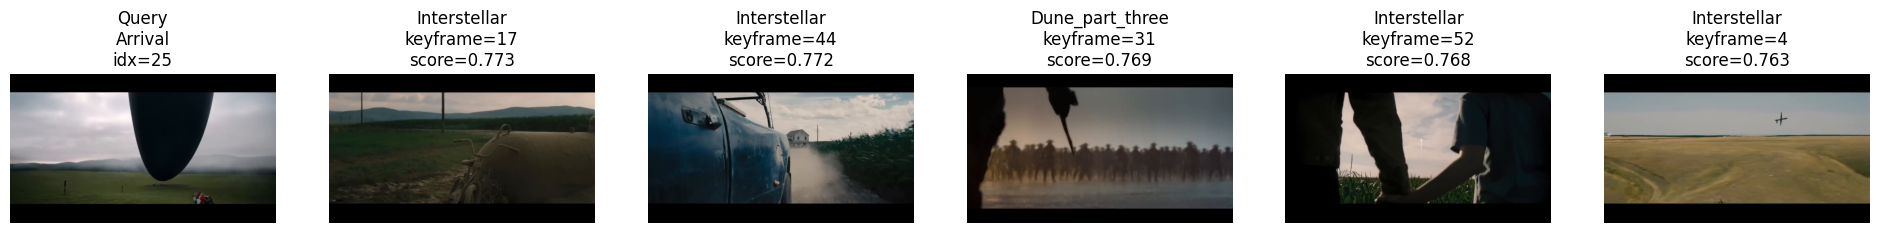

[(np.float32(0.7732467), np.int64(269)),
 (np.float32(0.77190614), np.int64(296)),
 (np.float32(0.76944435), np.int64(221)),
 (np.float32(0.7683628), np.int64(304)),
 (np.float32(0.7625084), np.int64(256))]

In [35]:
search_cross_movie(query_idx=25, all_image_paths = all_image_paths, metadata= metadata,  all_vectors=all_vectors, index_ip=index_ip, k=5, search_k=30)

In [36]:
print(metadata[0])
print(metadata[0].keys())

{'movie_title': 'Arrival', 'keyframe_idx': 0, 'image_path': '/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p/Arrival-Trailer_720p-Scene-001-01.jpg'}
dict_keys(['movie_title', 'keyframe_idx', 'image_path'])


In [37]:
len(all_image_paths) == len(metadata) == len(all_vectors)

True

In [38]:
all_image_paths[25] == metadata[25]["image_path"]

False

In [39]:
print(np.linalg.norm(all_vectors[0]))
print(np.linalg.norm(all_vectors[25]))

1.0
1.0


1. "분위기는 비슷하지만 내용이 다른 프레임이 검색됨"

2. CLIP은 색감/조명 같은 visual feature에 강하게 반응하고, 객체나 행동 같은 semantic content는 상대적으로 약하게 인코딩함

3. CLIP만 단독으로 사용하는 대신, DINOv2나 ResNet처럼 시각적 형태와 구조를 더 잘 반영하는 모델과 함께 비교하면 객체 중심 유사도를 보완할 수 있다

결론 : CLIP 기반 retrieval은 전체 장면의 분위기와 의미적 유사성은 어느 정도 잡지만,

사용자가 기대하는 특정 객체의 형태나 시각적 핵심 요소는 놓칠 수 있다.

## 텍스트 검색 시각화


In [40]:
import torch

def extract_text_embedding(text, model, processor, device):
  model = model.to(device)
  model.eval()

  inputs = processor(
      text = [text],
      return_tensors="pt",
      padding=True,
      truncation=True,
  ).to(device)

  with torch.no_grad():
    text_outputs = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

    text_features = text_outputs.pooler_output
    text_features = model.text_projection(text_features)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

  text_vector = text_features.cpu().numpy().astype("float32")

  faiss.normalize_L2(text_vector)

  print(type(text_features))
  print(text_features.shape)
  print(text_features[0][:10])

  return text_vector

In [41]:
def search_text_scene(text_query, index_ip, metadata, model, processor, device, all_image_paths, k=5, search_k=30, exclude_movie=None):
      text_vector = extract_text_embedding(text_query, model, processor, device)

      scores, indices = index_ip.search(text_vector, search_k)

      results =[]

      for score, idx in zip(scores[0], indices[0]):
          result_meta = metadata[idx]

          if exclude_movie is not None and result_meta["movie_title"] == exclude_movie:
            continue

          results.append((score, idx))

          if len(results) ==k:
            break

      total_cols = len(results)
      plt.figure(figsize=(4 * total_cols, 4))


      for i, (score, idx) in enumerate(results, start=1):
          img = Image.open(all_image_paths[idx])
          meta = metadata[idx]

          movie_title = meta["movie_title"]
          keyframe_idx = meta["keyframe_idx"]


          plt.subplot(1, k, i)
          plt.imshow(img)
          plt.axis("off")
          plt.title(
              f"{movie_title}\nkeyframe {keyframe_idx}\nscore {score:.3f}",
              fontsize=10
          )

      plt.tight_layout()
      plt.show()

      return results



<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([ 0.0376,  0.0254, -0.0344,  0.0059,  0.0254,  0.0250, -0.0638, -0.0498,
         0.0606,  0.0455])


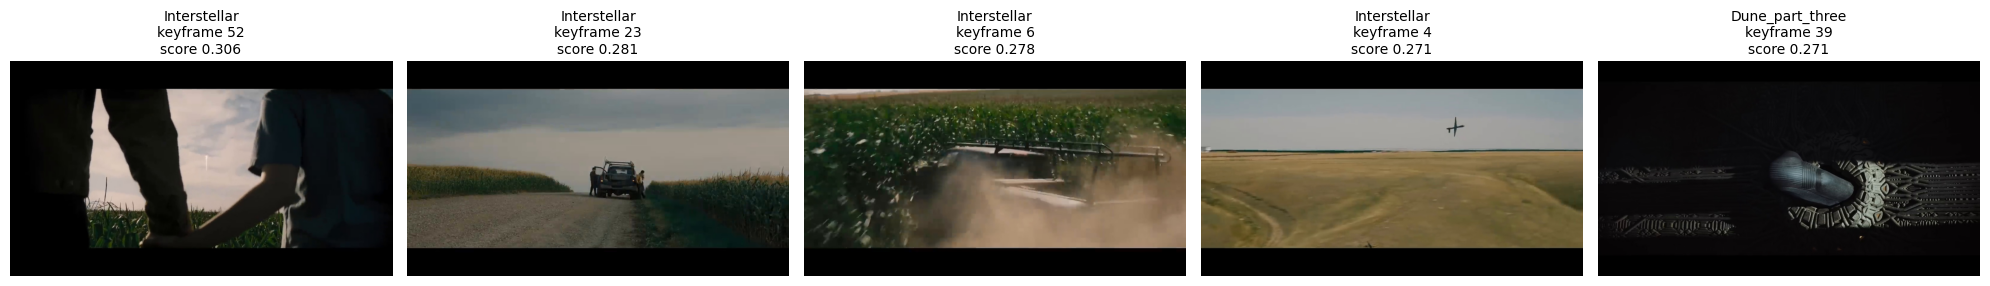

[(np.float32(0.30645403), np.int64(304)),
 (np.float32(0.28112662), np.int64(275)),
 (np.float32(0.27839103), np.int64(258)),
 (np.float32(0.27130556), np.int64(256)),
 (np.float32(0.27085006), np.int64(229))]

In [42]:
search_text_scene(
                  text_query="a giant black alien object over a field",
                  index_ip= index_ip,
                  metadata= metadata,
                  model=model,
                  processor= processor,
                  device= device,
                  all_image_paths=all_image_paths,
                  k=5,
                  search_k=30,
                  exclude_movie= "Arrival"
  )

Arrival을 제외한 상태에서 Arrival 고유 장면을 설명하는 텍스트 쿼리를 입력했을 때, 검색 결과는 실제의미와 맞지않는 장면을 반환했다.

이는 데이터셋 내에  해당장면과 대응하는 시각적인 후보가 없을 경우,

CLIP 은 전체 문장 의미보다 field, dark tone, sci-fi object 같은 부분

단서에 기반해 검색했다.



In [43]:
# 의미없는 매개변수 exclude_movie 지우고  max_per_movie 넣기

def search_text_scene(text_query, index_ip, metadata, model, processor, device, all_image_paths, k=5, search_k=30, max_per_movie=2):
  text_vector = extract_text_embedding(text_query, model, processor, device)

  scores, indices = index_ip.search(text_vector, search_k)

  results= []
  movie_count = {}

  for score , idx in zip(scores[0], indices[0]):
      result_meta = metadata[idx]
      movie_title = result_meta["movie_title"]

      if movie_count.get(movie_title, 0) >= max_per_movie:
        continue

      results.append((score, idx))
      movie_count[movie_title] = movie_count.get(movie_title, 0) + 1

      if len(results) == k:
        break


  plt.figure(figsize=(4 * len(results), 4))

  for i,(score, idx) in enumerate(results, start=1):
      img = Image.open(all_image_paths[idx])
      meta = metadata[idx]

      plt.subplot(1, len(results), i)
      plt.imshow(img)
      plt.axis("off")
      plt.title(
              f"{meta['movie_title']}\n"
              f"keyframe {meta['keyframe_idx']}\n"
              f"score {score:.3f}"
          )

  plt.show()


  return results


<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([ 0.0376,  0.0254, -0.0344,  0.0059,  0.0254,  0.0250, -0.0638, -0.0498,
         0.0606,  0.0455])


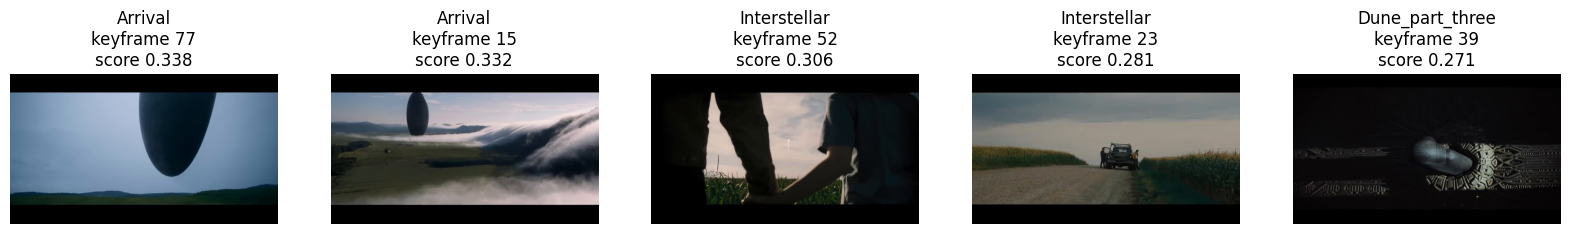

[(np.float32(0.33770216), np.int64(77)),
 (np.float32(0.33183098), np.int64(15)),
 (np.float32(0.30645403), np.int64(304)),
 (np.float32(0.28112662), np.int64(275)),
 (np.float32(0.27085006), np.int64(229))]

In [44]:
search_text_scene(
                  text_query="a giant black alien object over a field",
                  index_ip= index_ip,
                  metadata= metadata,
                  model=model,
                  processor= processor,
                  device= device,
                  all_image_paths=all_image_paths,
                  k=5,
                  search_k=30,
                  max_per_movie=2
  )

In [45]:
pip install umap-learn


In [46]:
!pip install -q umap-learn gradio plotly

In [47]:


# reducer = umap.UMAP(
#     n_neighbors=15,
#     min_dist = 0.1,
#     n_components=2,
#     metric ='cosine',
#     random_state=42

# )
# embedding = reducer.fit_transform(vectors_ip)
# embedding.shape


In [48]:
import umap
import plotly.express as px
import umap.umap_ as umap
import pandas as pd


def visualize_umap(n_neighbors=15, min_dist=0.1, color_by="movie_title"):
  reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist = min_dist,
    n_components=2,
    metric ='cosine',
    random_state=42

)
  embedding = reducer.fit_transform(all_vectors)


  df = pd.DataFrame({
      "x":embedding[:, 0],
      "y":embedding[:, 1],
      "movie_title": [meta["movie_title"] for meta in metadata],
      "keyframe_idx": [meta["keyframe_idx"] for meta in metadata],
      "image_path": [meta["image_path"] for meta in metadata]
  })

  fig = px.scatter(
        df,
        x="x",
        y="y",
        color=color_by,
        hover_data=["movie_title", "keyframe_idx", "image_path"],
        title="UMAP Visualization of CLIP Keyframe Embeddings"
    )

  return fig





In [49]:
print(vectors_ip.shape)
print(len(metadata))
print(type(vectors_ip))
print(metadata[0])

(110, 512)
450
<class 'numpy.ndarray'>
{'movie_title': 'Arrival', 'keyframe_idx': 0, 'image_path': '/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p/Arrival-Trailer_720p-Scene-001-01.jpg'}


In [50]:
embedding = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
).fit_transform(vectors_ip)


print("embedding 길이:", embedding.shape[0])
print("metadata 길이:", len(metadata))
print("vectors_ip 길이:", vectors_ip.shape[0])

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


embedding 길이: 110
metadata 길이: 450
vectors_ip 길이: 110


In [51]:
import gradio as gr

demo =  gr.Interface(
    fn=visualize_umap,
    inputs=[
            gr.Slider(2, 50, value=15, step=1, label= "n_neighbors"),
            gr.Slider(0.0,1.0, value=0.1, step=0.05, label="min_dist"),
            gr.Dropdown(
                choices =["movie_title", "keyframe_idx"], value="movie_title", label="Color by")],

    outputs=gr.Plot(),
    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7408b21118fbdc5ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [52]:
fig = visualize_umap(15, 0.1, "movie_title")
fig.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


movie_title 라벨 시각화는 각 키프레임을 영화별 색상으로 구분하고, CLIP 임베딩을 기준으로 시각적으로 유사한 키프레임들이 2차원 공간에 어떻게 분포하는지 보여준다. 가까운 점들은 시각적으로 유사한 장면으로 해석할 수 있고, 서로 다른 영화의 점들이 섞여 있다면 영화가 달라도 유사한 장면들이 존재한다는 의미이다.


keyframe_idx 라벨 시각화는 각 키프레임이 트레일러 안에서 몇 번째 장면인지 색상으로 구분하고, CLIP 임베딩을 기준으로 시각적으로 유사한 키프레임들이 2차원 공간에 어떻게 분포하는지 보여준다.

가까운 점들은 순서와 관계없이 시각적으로 유사한 장면으로 해석할 수 있으며, 색상이 연속적으로 이어지지 않는다면 트레일러의 시간 순서와 시각적 유사도가 반드시 일치하지 않는다는 의미이다.

# 검색 결과 평가 및 실패 사례 분석

<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0154, -0.0027, -0.0184, -0.0022, -0.0012, -0.0211,  0.0075, -0.0570,
        -0.0066,  0.0339])


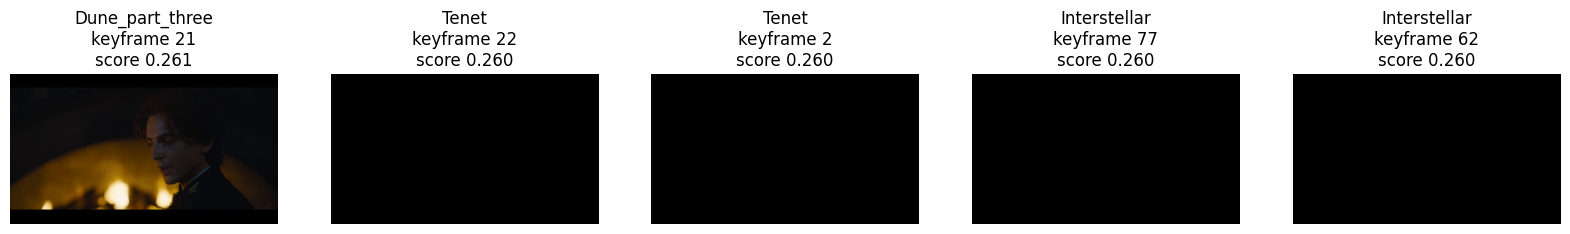

[(np.float32(0.2606029), np.int64(211)),
 (np.float32(0.26030326), np.int64(352)),
 (np.float32(0.26030326), np.int64(332)),
 (np.float32(0.26030326), np.int64(329)),
 (np.float32(0.26030326), np.int64(314))]

In [53]:
search_text_scene(
                  text_query="a close-up face in a dark room",
                  index_ip= index_ip,
                  metadata= metadata,
                  model=model,
                  processor= processor,
                  device= device,
                  all_image_paths=all_image_paths,
                  k=5,
                  search_k=30,
                  max_per_movie=2
  )

In [54]:
test_queries = [
    "a person standing in front of a giant alien structure",
    "a wide desert landscape with sand dunes",
    "a futuristic city street at night with neon lights",
    "a spaceship flying in outer space",
    "a close-up shot of a serious human face",
    "a dark room with blue lighting",
    "a bright light shining behind a silhouette"
]

QUERY: a person standing in front of a giant alien structure
<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0174,  0.0242, -0.0347,  0.0328, -0.0577,  0.0095, -0.0140, -0.0800,
         0.0184, -0.0045])


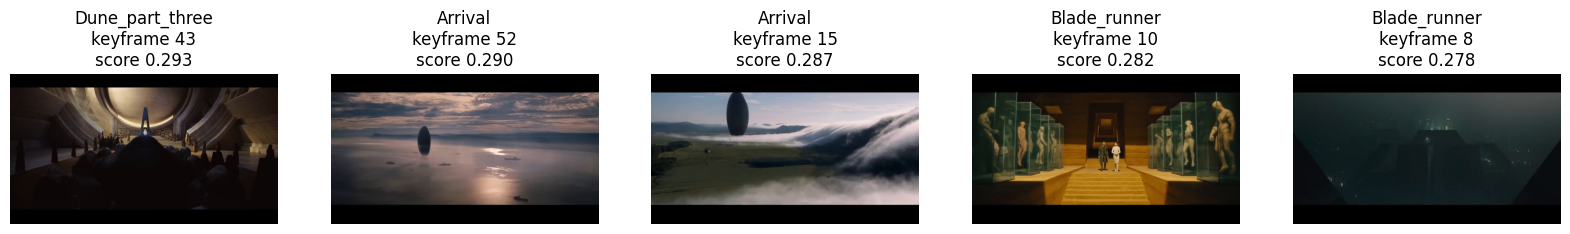

QUERY: a wide desert landscape with sand dunes
<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0108,  0.0003,  0.0049,  0.0007,  0.0062,  0.0174, -0.0538, -0.0293,
         0.0340,  0.0199])


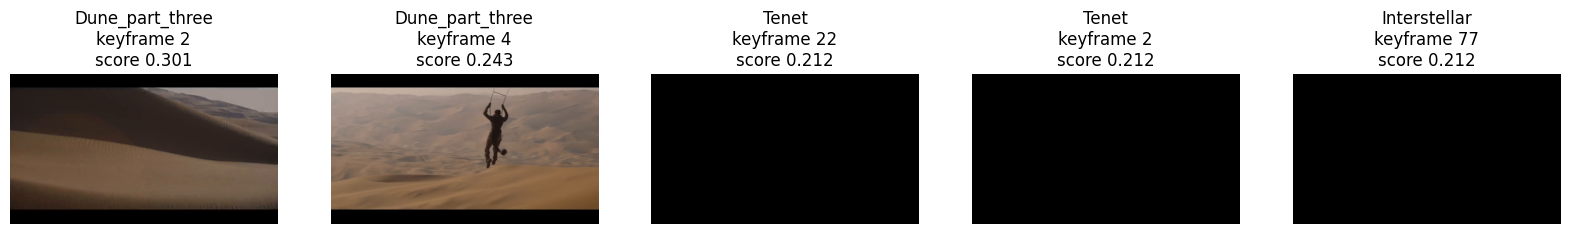

QUERY: a futuristic city street at night with neon lights
<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0160, -0.0087, -0.0055, -0.0564,  0.0071, -0.0119, -0.0548, -0.0300,
         0.0198,  0.0037])


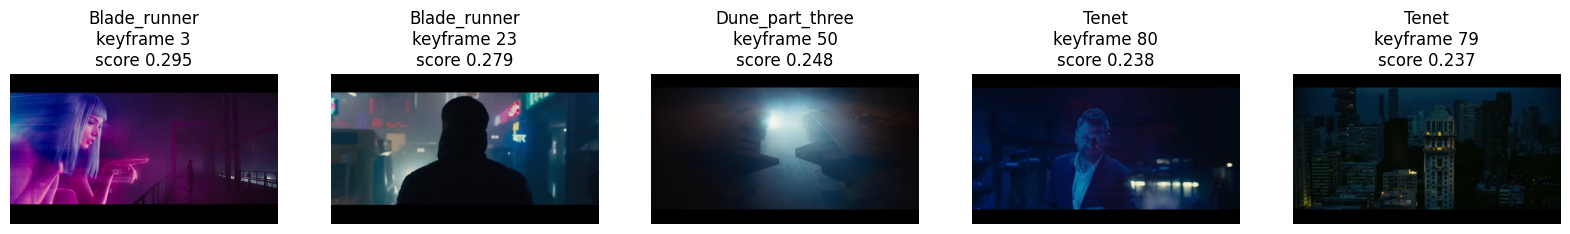

QUERY: a spaceship flying in outer space
<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([ 0.0032, -0.0051,  0.0031, -0.0167,  0.0102,  0.0288, -0.0233, -0.0966,
        -0.0249,  0.0008])


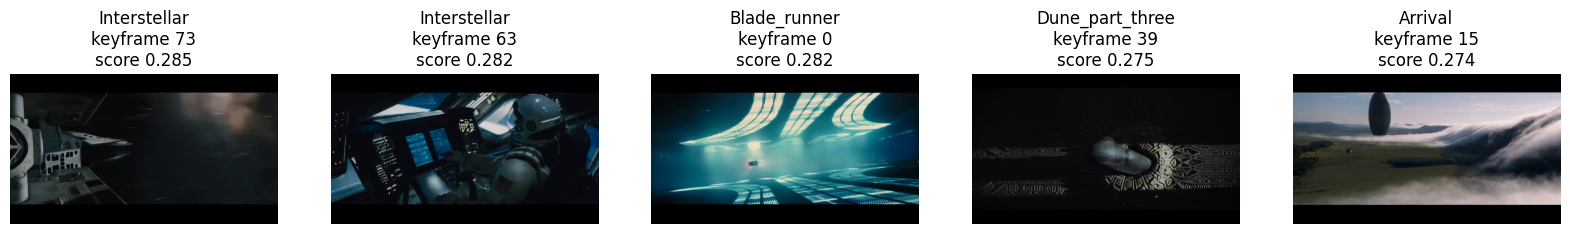

QUERY: a close-up shot of a serious human face
<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0086,  0.0032, -0.0458,  0.0260, -0.0153, -0.0119, -0.0163, -0.0641,
        -0.0051,  0.0038])


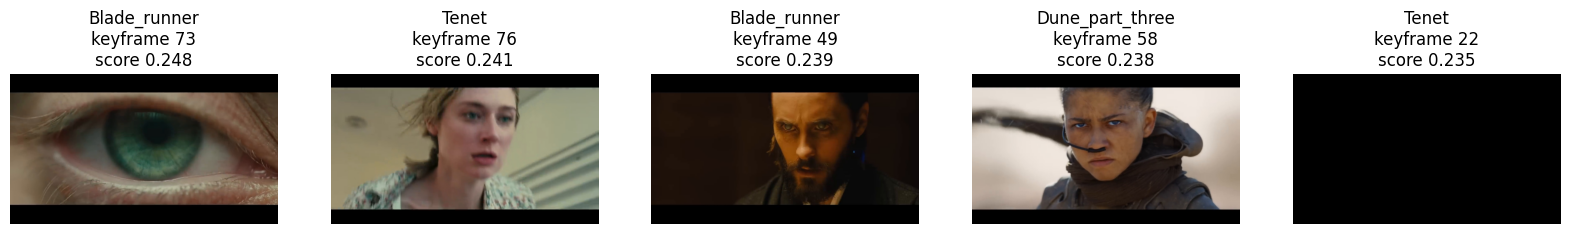

QUERY: a dark room with blue lighting
<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0121,  0.0091,  0.0122,  0.0015,  0.0116, -0.0256, -0.0163, -0.0761,
        -0.0023,  0.0237])


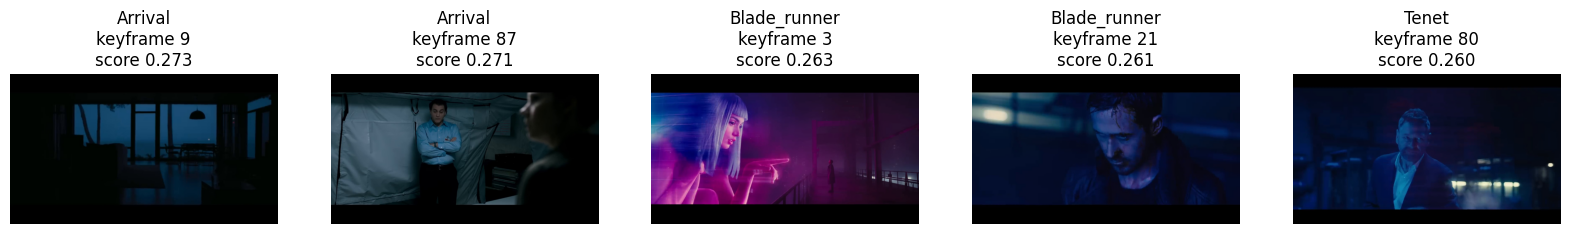

QUERY: a bright light shining behind a silhouette
<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0147, -0.0130,  0.0011,  0.0165,  0.0370, -0.0269,  0.0019, -0.1343,
         0.0037,  0.0507])


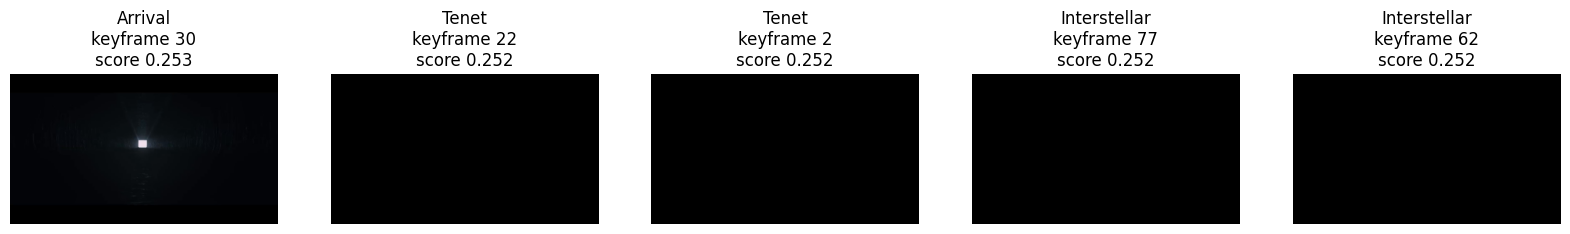

In [55]:
for query in test_queries:
  print('QUERY:', query)
  search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
    )

총 7개의 텍스트 이미지 결과 값을  4가지로 분류했다



1. Object Failure
쿼리의 핵심 물체를 못 찾음
예: cup, weapon, machine, alien structure

2. Relation Failure
객체 간 관계를 못 잡음
예: in front of, holding, reaching, next to

3. Action Failure
행동 의미를 못 잡음
예: standing, running, opening, reaching

4. Context Bias
분위기만 보고 맞다고 착각함
예: dark, neon, desert, futuristic



Query: a person standing in front of a giant alien structure

Result: Partial

Reason:
검색 결과 일부는 거대한 구조물이나 외계 물체와 관련된 장면을 포함했지만,
'person standing in front of'라는 구체적인 관계는 명확하게 반영되지 않았다.
CLIP은 구조물, 어두운 분위기, SF적 배경에는 반응했지만,
텍스트 쿼리의 세부 관계까지는 정확히 구분하지 못했다.

Query: a wide desert landscape with sand dunes

Result: Partial

일부 사막 장면은 검색되었지만, 어두운 프레임도 함께 반환되었다. 이는 CLIP 임베딩이 색감이나 장면 분위기에는 반응했지만, 키프레임 품질과 쿼리 의미를 안정적으로 분리하지 못한 사례로 볼 수 있다. 따라서 해당 결과는 성공보다는 부분 성공(Partial)에 가깝다.





QUERY: a spaceship flying in outer space ----  Result: Partial

QUERY: a close-up shot of a serious human face ---  Result: Partial

QUERY: a dark room with blue lighting ---- Result: Partial

QUERY: a bright light shining behind a silhouette ---- Result: Partial





